In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
Rollno = [1,2,3,4,5,6,7,8,9,10]
Name = ['A','B','C','D','E','F','G','H','I','J']
Marks = [40,50,30,np.nan,50,70,98,np.nan,95,91]

In [3]:
df = pd.DataFrame({"Rollno":Rollno , "Name":Name , "Marks":Marks})

In [4]:
df

,Rollno,Name,Marks
0,1,A,40.0
1,2,B,50.0
2,3,C,30.0
3,4,D,NaN
4,5,E,50.0
5,6,F,70.0
6,7,G,98.0
7,8,H,NaN
8,9,I,95.0
9,10,J,91.0


* 1. Scan all variables for missing values and inconsistencies. If there are missing values and/or
inconsistencies, use any of the suitable techniques to deal with them. 

In [5]:
df['Marks'] = df['Marks'].fillna(df['Marks'].mean())

In [6]:
df

,Rollno,Name,Marks
0,1,A,40.0
1,2,B,50.0
2,3,C,30.0
3,4,D,65.5
4,5,E,50.0
5,6,F,70.0
6,7,G,98.0
7,8,H,65.5
8,9,I,95.0
9,10,J,91.0


In [7]:
df.dtypes

Rollno      int64
Name       object
Marks     float64
dtype: object

In [8]:
df['Marks'] = df['Marks'].astype(int)

In [9]:
df.dtypes

Rollno     int64
Name      object
Marks      int64
dtype: object

In [10]:
df

,Rollno,Name,Marks
0,1,A,40
1,2,B,50
2,3,C,30
3,4,D,65
4,5,E,50
5,6,F,70
6,7,G,98
7,8,H,65
8,9,I,95
9,10,J,91


In [11]:
def grd(value):
    if value>=40:
        return "P"
    else:
        return "F"

In [12]:
df['Grades'] = df['Marks'].apply(grd)

In [13]:
df

,Rollno,Name,Marks,Grades
0,1,A,40,P
1,2,B,50,P
2,3,C,30,F
3,4,D,65,P
4,5,E,50,P
5,6,F,70,P
6,7,G,98,P
7,8,H,65,P
8,9,I,95,P
9,10,J,91,P


* Scan all numeric variables for outliers. If there are outliers, use any of the suitable
techniques to deal with them.

In [14]:
first_outlier = [11,'K',200,'P']
second_outlier = [12,'L',-100,'F']


In [15]:
df.loc[10] = first_outlier
df.loc[11] = second_outlier
df

,Rollno,Name,Marks,Grades
0,1,A,40,P
1,2,B,50,P
2,3,C,30,F
3,4,D,65,P
4,5,E,50,P
5,6,F,70,P
6,7,G,98,P
7,8,H,65,P
8,9,I,95,P
9,10,J,91,P


In [16]:
df.dtypes

Rollno     int64
Name      object
Marks      int64
Grades    object
dtype: object

<Axes: xlabel='Marks'>

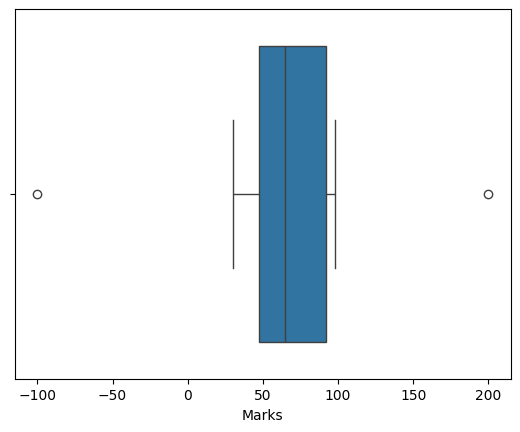

In [17]:
sns.boxplot(data = df, x= 'Marks')

In [18]:

Q1 = df['Marks'].quantile(0.25)
Q3 = df['Marks'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
higher = Q3 + 1.5 * IQR

outliers = df[(df['Marks'] < lower) | (df['Marks'] > higher)]

outliers

,Rollno,Name,Marks,Grades
10,11,K,200,P
11,12,L,-100,F


In [24]:
df = df[(df['Marks'] >= lower) & (df['Marks'] <= higher)].copy()

In [25]:
df

,Rollno,Name,Marks,Grades,Marks_Scaler
0,1,A,40,P,0.147059
1,2,B,50,P,0.294118
2,3,C,30,F,0.000000
3,4,D,65,P,0.514706
4,5,E,50,P,0.294118
5,6,F,70,P,0.588235
6,7,G,98,P,1.000000
7,8,H,65,P,0.514706
8,9,I,95,P,0.955882
9,10,J,91,P,0.897059


*  Apply data transformations on at least one of the variables. The purpose of this
transformation should be one of the following reasons: to change the scale for better
understanding of the variable, to convert a non-linear relation into a linear one, or to
decrease the skewness and convert the distribution into a normal distribution. 

In [26]:
scaler = MinMaxScaler()
df['Marks_Scaler'] = scaler.fit_transform(df[['Marks']])
df

,Rollno,Name,Marks,Grades,Marks_Scaler
0,1,A,40,P,0.147059
1,2,B,50,P,0.294118
2,3,C,30,F,0.000000
3,4,D,65,P,0.514706
4,5,E,50,P,0.294118
5,6,F,70,P,0.588235
6,7,G,98,P,1.000000
7,8,H,65,P,0.514706
8,9,I,95,P,0.955882
9,10,J,91,P,0.897059


In [22]:
df.describe()

,Rollno,Marks,Marks_Scaler
count,10.00000,10.000000,10.000000
mean,5.50000,65.400000,0.520588
std,3.02765,23.542869,0.346219
min,1.00000,30.000000,0.000000
25%,3.25000,50.000000,0.294118
50%,5.50000,65.000000,0.514706
75%,7.75000,85.750000,0.819853
max,10.00000,98.000000,1.000000


In [27]:
df.to_csv("AccadmicInfo.csv")